In [1]:
# --------------------------------
# Imports & Path Setup
# --------------------------------

%reload_ext autoreload
%autoreload 2

import os
print(os.getcwd())

import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))

import numpy as np
import matplotlib.pyplot as plt
import torch
from skimage.metrics import peak_signal_noise_ratio as calc_psnr
from skimage.metrics import structural_similarity as calc_ssim

from src.utils.trainer import Trainer
from src.utils.logger import Logger

/hpc/home/efavale/deep-image-restoration


In [2]:
# --------------------------------
# Trainer Setup
# --------------------------------

LOG_DIR = Path("logs")

RESIZED_DIR = Path("data/resized")
COMPRESSED_DIR = Path("data/compressed")
CHECKPOINTS_DIR = Path("checkpoints")

logger = Logger(
    dir=LOG_DIR,
    description="ConvAutoencoder-SkipConnections-BothCompressions-ExtendedDataset"
)

# ConvAutoencoder
trainer = Trainer(
    input_dir=RESIZED_DIR,
    compressed_dir=COMPRESSED_DIR,
    checkpoints_dir=CHECKPOINTS_DIR,
    checkpoint_name="best_model_autoencoder",
    logger=logger,
    base_channels=32,
    batch_size=4,
    learning_rate=1e-3,
    weight_decay=1e-4,
)

trainer.load_dataset()

Device : cuda
Parameters : 2,389,859
Train	| Val	| Test : 
700	| 150	| 150


/hpc/home/efavale/miniconda3/envs/deep-image-restoration/lib/python3.12/site-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 2 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [3]:
# --------------------------------
# Training
# --------------------------------

history = trainer.train(num_epochs=100)

/hpc/home/efavale/miniconda3/envs/deep-image-restoration/lib/python3.12/site-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 2 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch   1/100  |  Train Loss: 0.170380  |  Val Loss:   0.121377
Epoch  10/100  |  Train Loss: 0.111803  |  Val Loss:   0.096806
Epoch  20/100  |  Train Loss: 0.106117  |  Val Loss:   0.092119
Epoch  30/100  |  Train Loss: 0.103407  |  Val Loss:   0.090306
Epoch  40/100  |  Train Loss: 0.101292  |  Val Loss:   0.089332
Epoch  50/100  |  Train Loss: 0.098463  |  Val Loss:   0.087369
Epoch  60/100  |  Train Loss: 0.094641  |  Val Loss:   0.087413
Epoch  70/100  |  Train Loss: 0.092685  |  Val Loss:   0.087127
Epoch  80/100  |  Train Loss: 0.090361  |  Val Loss:   0.086634
Epoch  90/100  |  Train Loss: 0.087753  |  Val Loss:   0.086543
Epoch 100/100  |  Train Loss: 0.087267  |  Val Loss:   0.086562

Training complete — Best val loss: 0.085963 (epoch 95)
Checkpoint saved: checkpoints/best_model_autoencoder_20260310_111257.pth
[Logger] Log saved to: logs/20260310_111257_ConvAutoencoder-SkipConnections-BothCompressions-ExtendedDataset.log


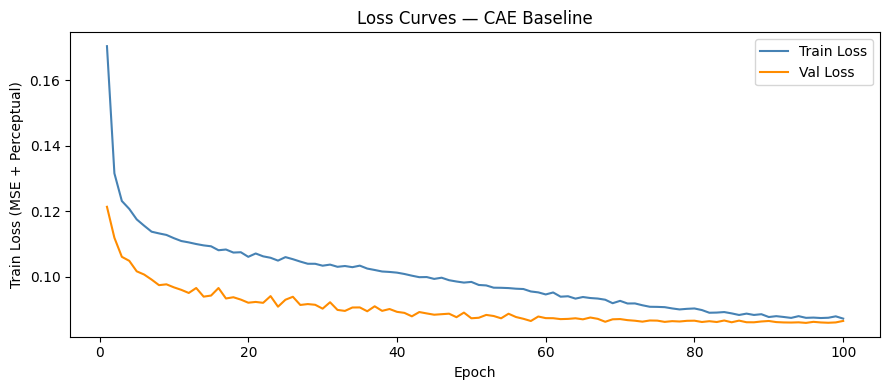

In [4]:
# --------------------------------
# Loss Curves
# --------------------------------

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(9, 4))
plt.plot(epochs, history["train_loss"], label="Train Loss", color="steelblue")
plt.plot(epochs, history["val_loss"], label="Val Loss", color="darkorange")
plt.xlabel("Epoch")
plt.ylabel("Train Loss (MSE + Perceptual)")
plt.title("Loss Curves — CAE Baseline")
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
# --------------------------------
# Load Best Checkpoint
# --------------------------------

trainer.model.load_state_dict(
    torch.load(
        Path("checkpoints/best_model_autoencoder.pth"), map_location=trainer.device
    )
)
trainer.model.eval()
print(" Best model loaded")

 Best model loaded


In [6]:
# --------------------------------
# Baseline PSNR — Compressed vs Original
# --------------------------------

psnr_baseline, ssim_baseline = [], []

for compressed, original in trainer.test_loader:
    for comp_t, orig_t in zip(compressed.numpy(), original.numpy()):
        comp_np = np.transpose(comp_t, (1, 2, 0))
        orig_np = np.transpose(orig_t, (1, 2, 0))
        psnr_baseline.append(calc_psnr(orig_np, comp_np, data_range=1.0))
        ssim_baseline.append(
            calc_ssim(orig_np, comp_np, data_range=1.0, channel_axis=2)
        )

psnr_base = np.mean(psnr_baseline)
ssim_base = np.mean(ssim_baseline)
print(f"Baseline  —  PSNR: {psnr_base:.2f} dB  |  SSIM: {ssim_base:.4f}")

Baseline  —  PSNR: 25.60 dB  |  SSIM: 0.7883


In [7]:
# --------------------------------
# PSNR / SSIM — Restored vs Original
# --------------------------------

psnr_list, ssim_list = [], []

with torch.no_grad():
    for compressed, original in trainer.test_loader:
        compressed = compressed.to(trainer.device)
        original = original.to(trainer.device)
        recon, _ = trainer.model(compressed)

        for out_t, orig_t in zip(recon.cpu().numpy(), original.cpu().numpy()):
            out_np = np.transpose(out_t, (1, 2, 0))
            orig_np = np.transpose(orig_t, (1, 2, 0))
            psnr_list.append(calc_psnr(orig_np, out_np, data_range=1.0))
            ssim_list.append(calc_ssim(orig_np, out_np, data_range=1.0, channel_axis=2))

psnr_mean = np.mean(psnr_list)
ssim_mean = np.mean(ssim_list)

print(f"{'─' * 50}")
print(f"  PSNR baseline (compressed) : {psnr_base:.2f} dB")
print(
    f"  PSNR restored              : {psnr_mean:.2f} dB  ({psnr_mean - psnr_base:+.2f})"
)
print(f"  SSIM baseline (compressed) : {ssim_base:.4f}")
print(f"  SSIM restored              : {ssim_mean:.4f}  ({ssim_mean - ssim_base:+.4f})")
print(f"{'─' * 50}")

──────────────────────────────────────────────────
  PSNR baseline (compressed) : 25.60 dB
  PSNR restored              : 24.38 dB  (-1.22)
  SSIM baseline (compressed) : 0.7883
  SSIM restored              : 0.6993  (-0.0890)
──────────────────────────────────────────────────
